In [1]:
import torch
torch.__version__

'2.11.0+cu126'

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap

In [3]:
df = pd.read_csv('https://raw.githubusercontent.com/Naman-Agrawal19/csv_data/refs/heads/main/loan_data.csv')

In [4]:
df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


In [5]:
df.shape

(45000, 14)

<table>
<thead>
<tr>
<th>Column</th>
<th>Description</th>
<th>Type</th>
</tr>
</thead>
<tbody>
<tr>
<p>The dataset contains 45,000 records and 14 variables, each described below:</p><td><code>person_age</code></td>
<td>Age of the person</td>
<td>Float</td>
</tr>
<tr>
<td><code>person_gender</code></td>
<td>Gender of the person</td>
<td>Categorical</td>
</tr>
<tr>
<td><code>person_education</code></td>
<td>Highest education level</td>
<td>Categorical</td>
</tr>
<tr>
<td><code>person_income</code></td>
<td>Annual income</td>
<td>Float</td>
</tr>
<tr>
<td><code>person_emp_exp</code></td>
<td>Years of employment experience</td>
<td>Integer</td>
</tr>
<tr>
<td><code>person_home_ownership</code></td>
<td>Home ownership status (e.g., rent, own, mortgage)</td>
<td>Categorical</td>
</tr>
<tr>
<td><code>loan_amnt</code></td>
<td>Loan amount requested</td>
<td>Float</td>
</tr>
<tr>
<td><code>loan_intent</code></td>
<td>Purpose of the loan</td>
<td>Categorical</td>
</tr>
<tr>
<td><code>loan_int_rate</code></td>
<td>Loan interest rate</td>
<td>Float</td>
</tr>
<tr>
<td><code>loan_percent_income</code></td>
<td>Loan amount as a percentage of annual income</td>
<td>Float</td>
</tr>
<tr>
<td><code>cb_person_cred_hist_length</code></td>
<td>Length of credit history in years</td>
<td>Float</td>
</tr>
<tr>
<td><code>credit_score</code></td>
<td>Credit score of the person</td>
<td>Integer</td>
</tr>
<tr>
<td><code>previous_loan_defaults_on_file</code></td>
<td>Indicator of previous loan defaults</td>
<td>Categorical</td>
</tr>
<tr>
<td><code>loan_status</code> (target variable)</td>
<td>Loan approval status: 1 = approved; 0 = rejected</td>
<td>Integer</td>
</tr>
</tbody>
</table>

In [6]:
df.isna().sum()

person_age                        0
person_gender                     0
person_education                  0
person_income                     0
person_emp_exp                    0
person_home_ownership             0
loan_amnt                         0
loan_intent                       0
loan_int_rate                     0
loan_percent_income               0
cb_person_cred_hist_length        0
credit_score                      0
previous_loan_defaults_on_file    0
loan_status                       0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

## eda

In [8]:
# separating numeric and categorical columns
numeric_data = df.select_dtypes(include=np.number)
categorical_data = df.select_dtypes(exclude=np.number)

In [9]:
numeric_data.sample(5)

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
14254,24.0,109107.0,0,19200.0,12.84,0.18,4.0,549,1
18818,31.0,18011.0,10,1250.0,11.01,0.07,8.0,670,1
3663,22.0,54921.0,0,3950.0,6.92,0.07,4.0,635,0
24674,31.0,85020.0,7,10000.0,11.01,0.12,8.0,676,0
41784,30.0,30133.0,7,5000.0,10.97,0.17,8.0,634,0


In [10]:
numeric_data.describe().T

,count,mean,std,min,25%,50%,75%,max
person_age,45000.0,27.764178,6.045108,20.00,24.00,26.00,30.00,144.00
person_income,45000.0,80319.053222,80422.498632,8000.00,47204.00,67048.00,95789.25,7200766.00
person_emp_exp,45000.0,5.410333,6.063532,0.00,1.00,4.00,8.00,125.00
loan_amnt,45000.0,9583.157556,6314.886691,500.00,5000.00,8000.00,12237.25,35000.00
loan_int_rate,45000.0,11.006606,2.978808,5.42,8.59,11.01,12.99,20.00
loan_percent_income,45000.0,0.139725,0.087212,0.00,0.07,0.12,0.19,0.66
cb_person_cred_hist_length,45000.0,5.867489,3.879702,2.00,3.00,4.00,8.00,30.00
credit_score,45000.0,632.608756,50.435865,390.00,601.00,640.00,670.00,850.00
loan_status,45000.0,0.222222,0.415744,0.00,0.00,0.00,0.00,1.00


In [11]:
df.query('person_age>70')

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
81,144.0,male,Bachelor,300616.0,125,RENT,4800.0,VENTURE,13.57,0.02,3.0,789,No,0
183,144.0,male,Associate,241424.0,121,MORTGAGE,6000.0,EDUCATION,11.86,0.02,2.0,807,No,0
575,123.0,female,High School,97140.0,101,RENT,20400.0,EDUCATION,10.25,0.21,3.0,805,Yes,0
747,123.0,male,Bachelor,94723.0,100,RENT,20000.0,VENTURE,11.01,0.21,4.0,714,Yes,0
32297,144.0,female,Associate,7200766.0,124,MORTGAGE,5000.0,PERSONAL,12.73,0.00,25.0,850,No,0
32355,78.0,male,Associate,58463.0,57,RENT,3000.0,MEDICAL,7.51,0.05,25.0,754,No,0
32381,73.0,female,Bachelor,51415.0,47,MORTGAGE,5000.0,PERSONAL,7.49,0.10,28.0,706,No,0
32416,94.0,male,High School,29738.0,76,RENT,6500.0,MEDICAL,11.01,0.22,27.0,773,No,0
32422,80.0,male,High School,77894.0,62,RENT,6800.0,MEDICAL,11.71,0.09,25.0,673,No,0
32432,73.0,male,Bachelor,90678.0,47,RENT,7800.0,MEDICAL,11.01,0.09,24.0,696,Yes,0


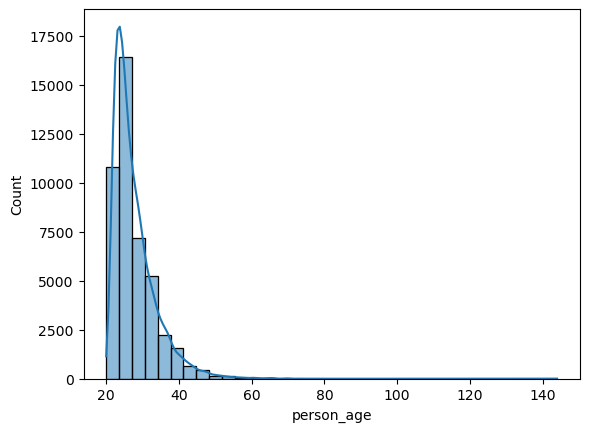

In [12]:
sns.histplot(x=df['person_age'], kde=True, bins = 35)
plt.show()

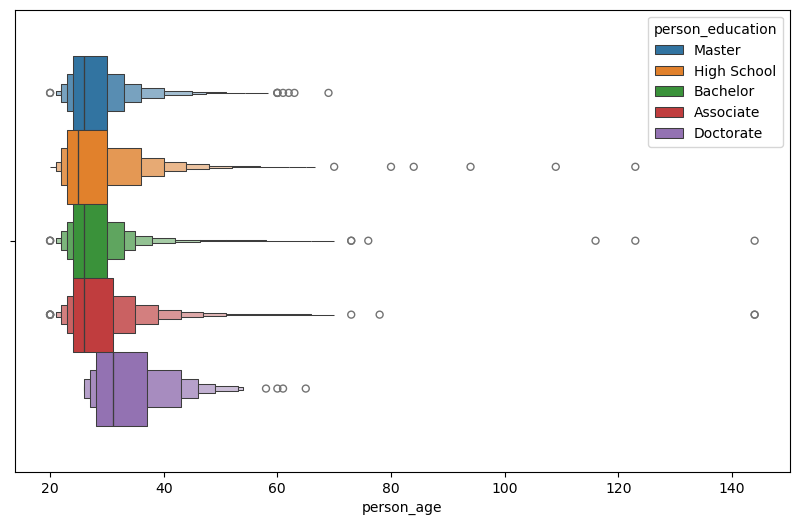

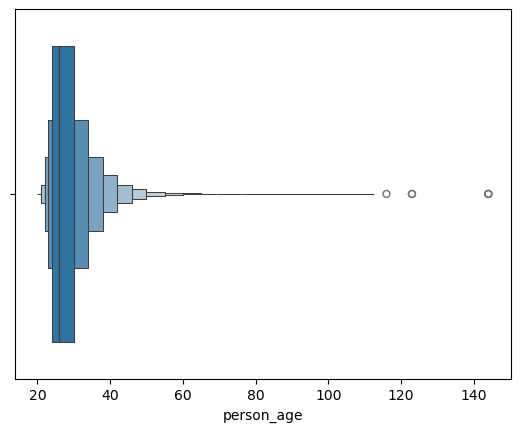

In [13]:
plt.figure(figsize=(10,6))
sns.boxenplot(x=df['person_age'], hue=df['person_education'])
plt.show()
sns.boxenplot(x=df['person_age'])
plt.show()

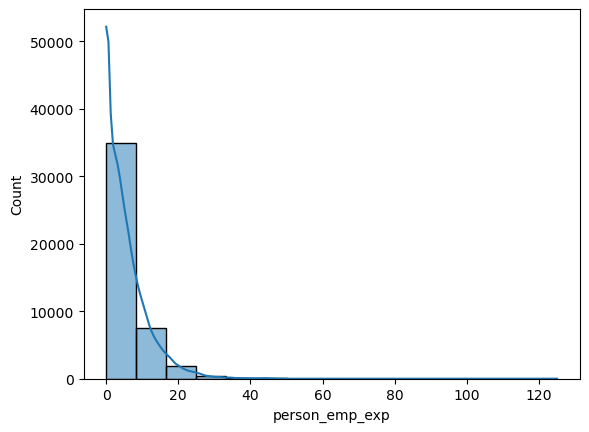

In [14]:
sns.histplot(df['person_emp_exp'], kde=True, bins=15)
plt.show()

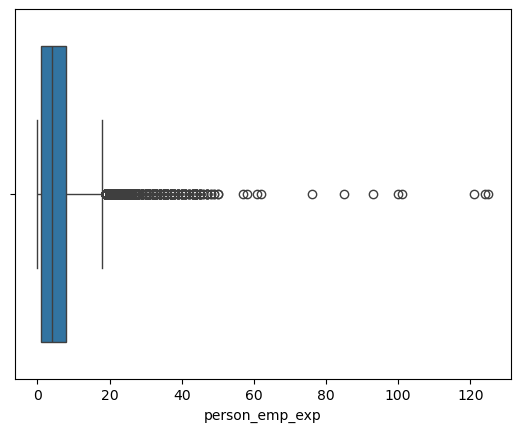

In [15]:
sns.boxplot(x=df['person_emp_exp'])
plt.show()

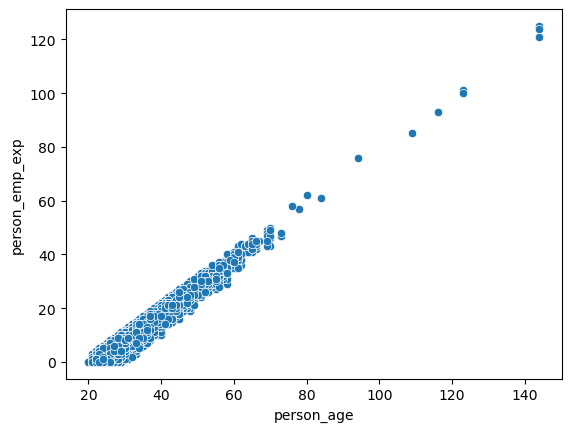

In [16]:
sns.scatterplot(x = 'person_age', y = 'person_emp_exp', data = df)
plt.show()

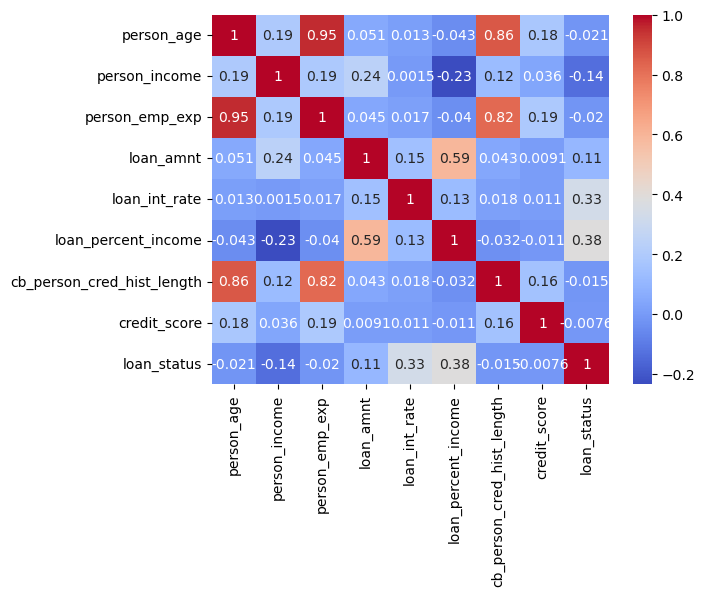

In [17]:
sns.heatmap(numeric_data.corr(), annot=True, cmap='coolwarm')
plt.show()

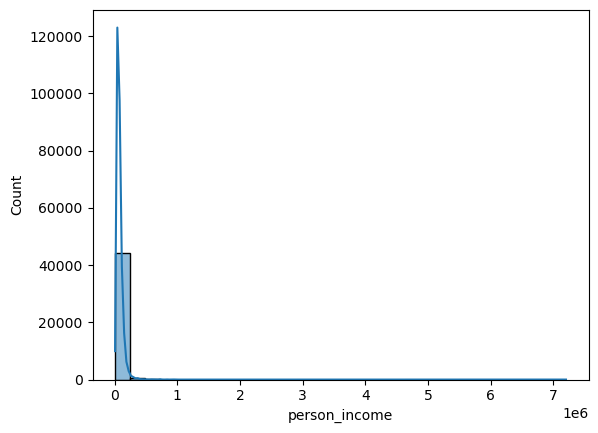

In [18]:
sns.histplot(numeric_data['person_income'], kde=True, bins=30)
plt.show()

<Axes: xlabel='person_income'>

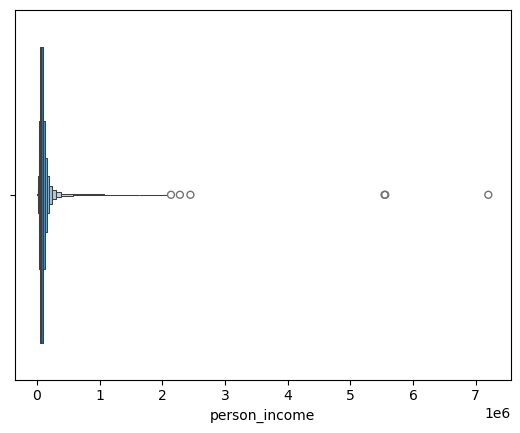

In [19]:
sns.boxenplot(x = numeric_data['person_income'])

<Axes: xlabel='loan_amnt', ylabel='Count'>

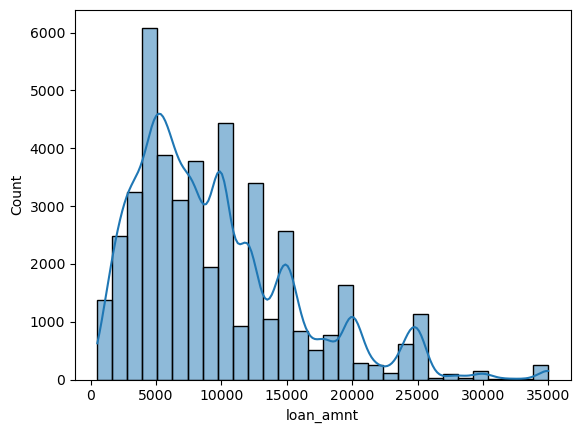

In [20]:
sns.histplot(df['loan_amnt'], bins=30, kde=True)

<Axes: xlabel='loan_amnt'>

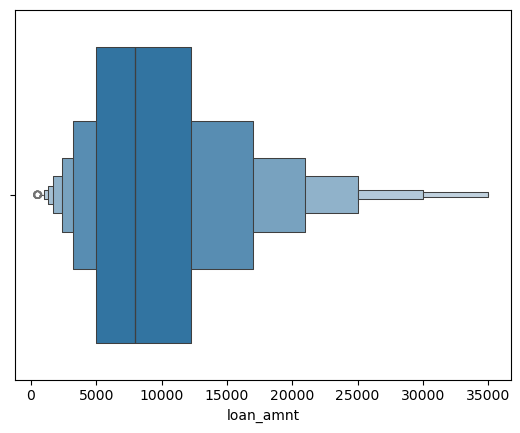

In [21]:
sns.boxenplot(x=df['loan_amnt'])

In [22]:
numeric_data.columns

Index(['person_age', 'person_income', 'person_emp_exp', 'loan_amnt',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length',
       'credit_score', 'loan_status'],
      dtype='str')

In [23]:
num_features = numeric_data.columns[:-1]
num_features

Index(['person_age', 'person_income', 'person_emp_exp', 'loan_amnt',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length',
       'credit_score'],
      dtype='str')

In [24]:
from matplotlib.gridspec import GridSpec
def numerical_plots(data, features):
    plt.figure(figsize=(15, 5))
    gs = GridSpec(1, 4)
    ax1 = plt.subplot(gs[0, 0]) # boxenplot
    ax2 = plt.subplot(gs[0, 1:3]) # histogram
    ax3 = plt.subplot(gs[0, 3]) # violin plot

    sns.boxenplot(data=data[features], ax=ax1)
    ax2.set_title(f'Plots for {features}')
    sns.histplot(x=data[features], kde=True, ax=ax2)
    sns.violinplot(data=data[features], ax=ax3)
    
    plt.tight_layout()
    plt.show()

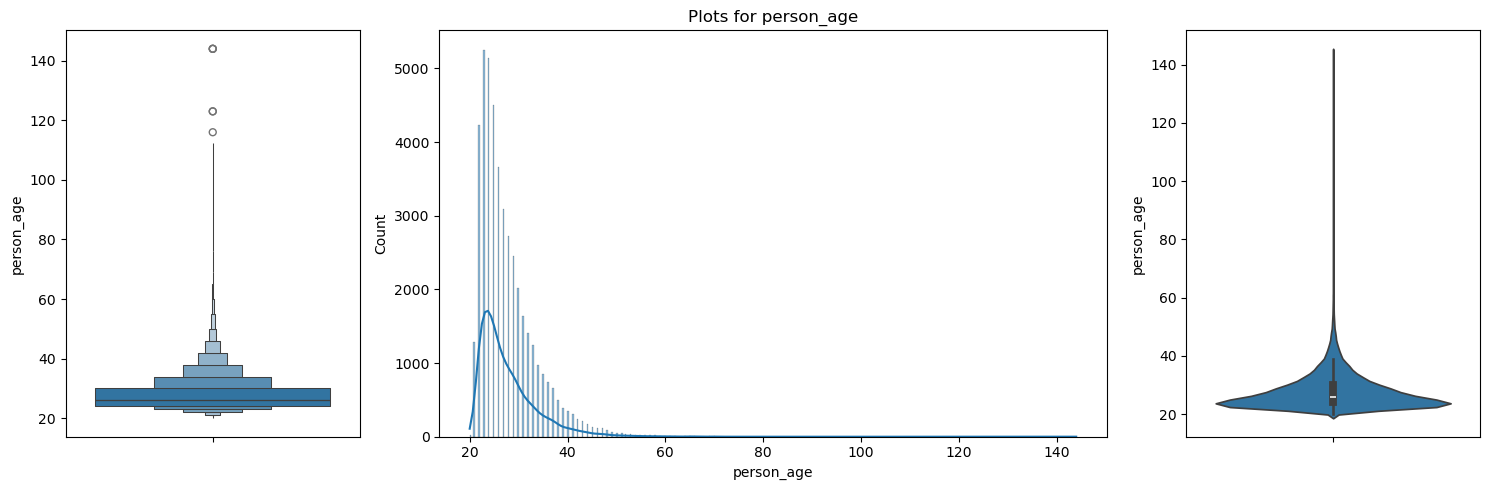

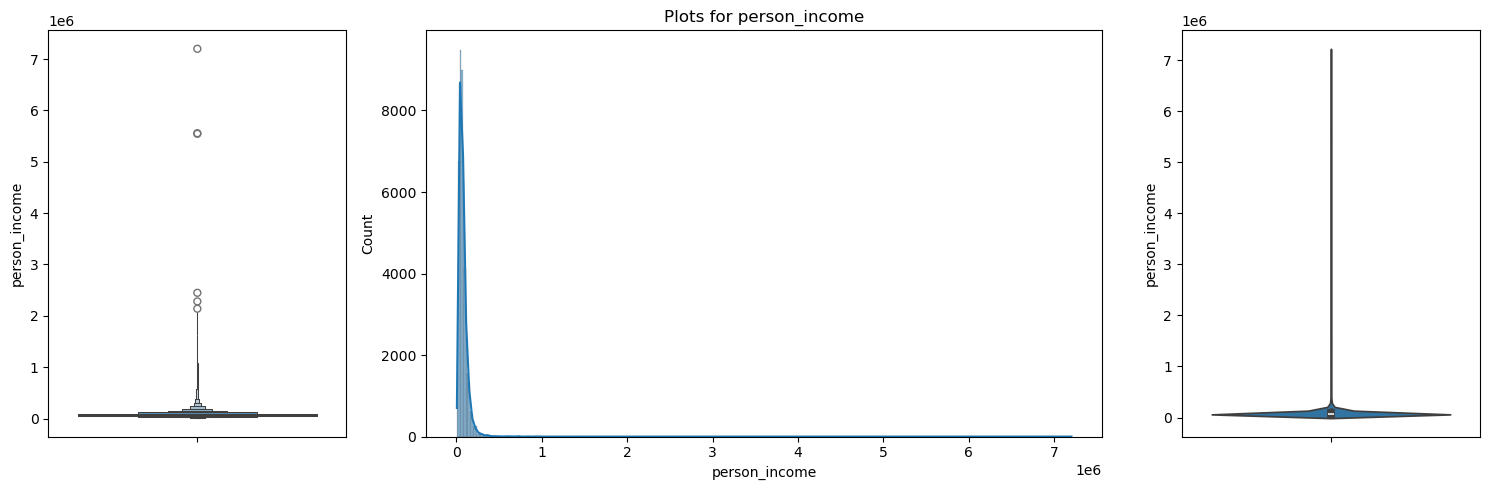

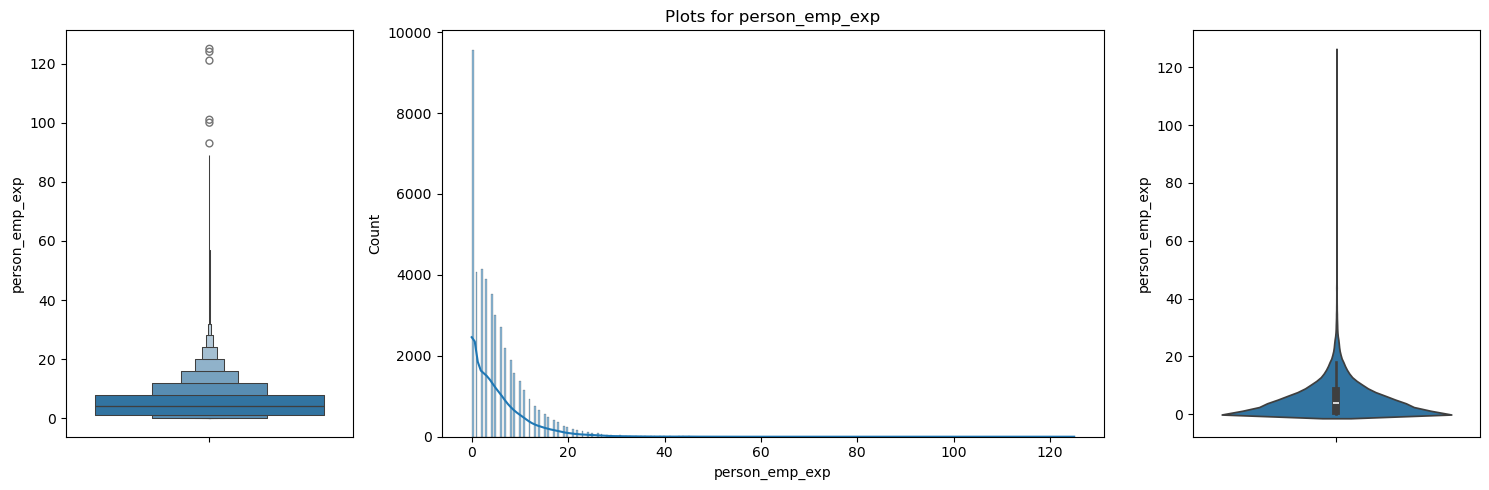

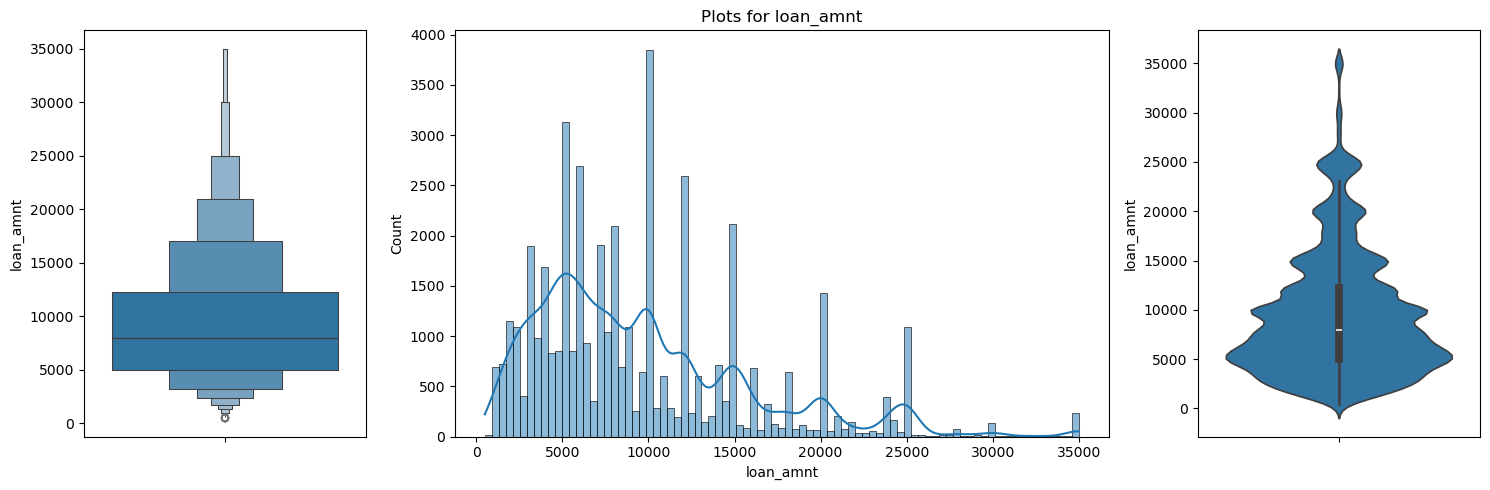

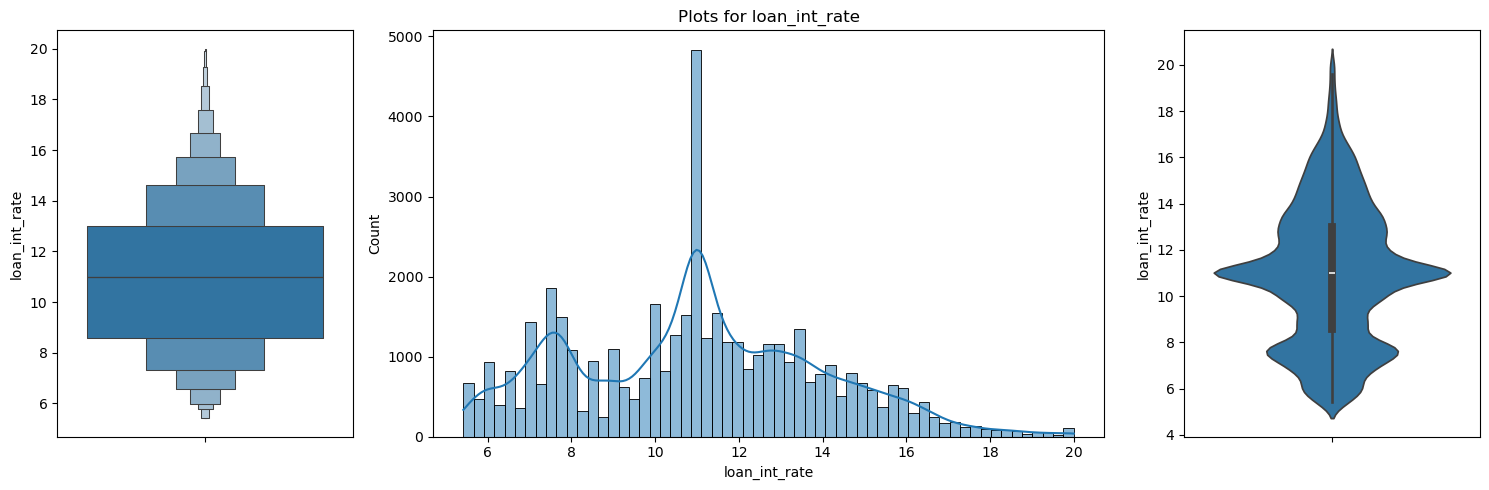

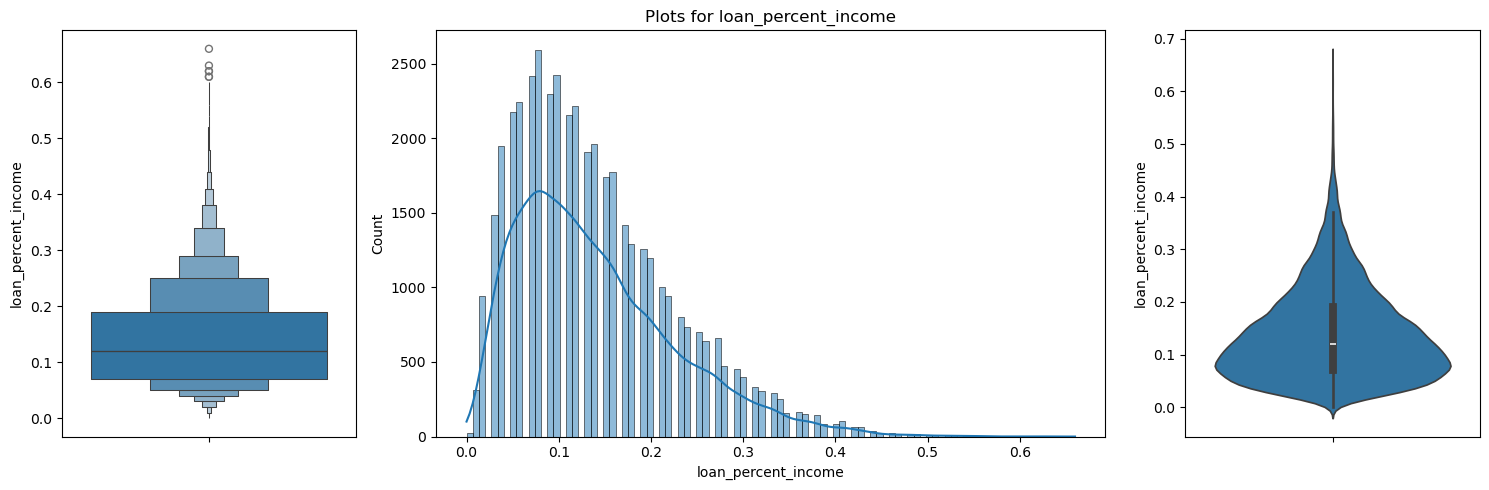

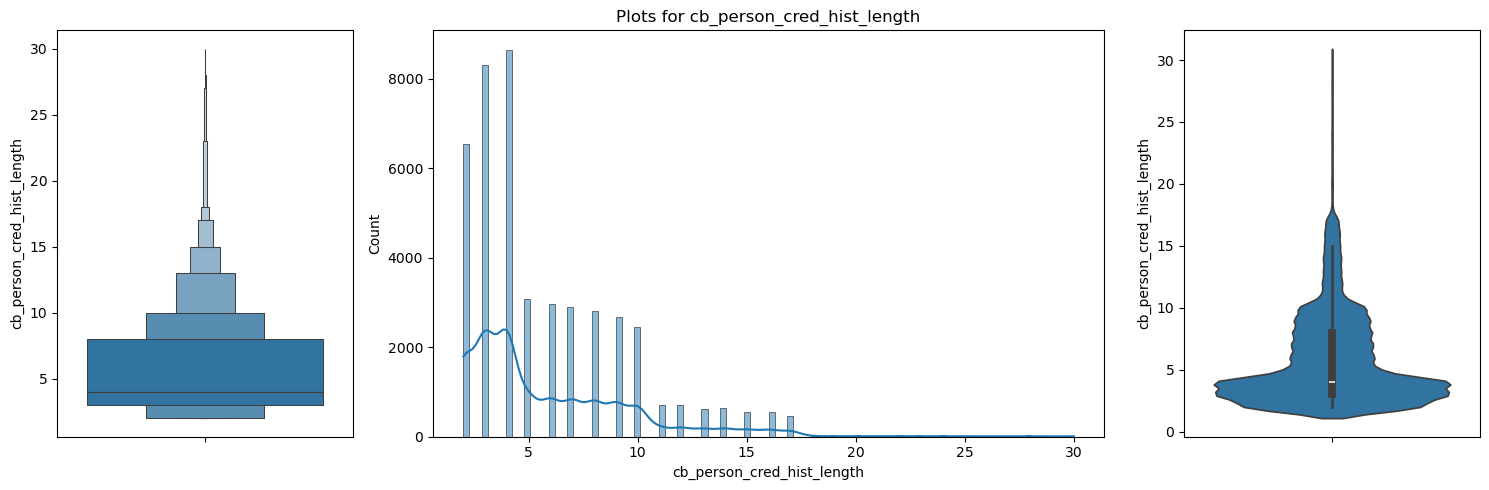

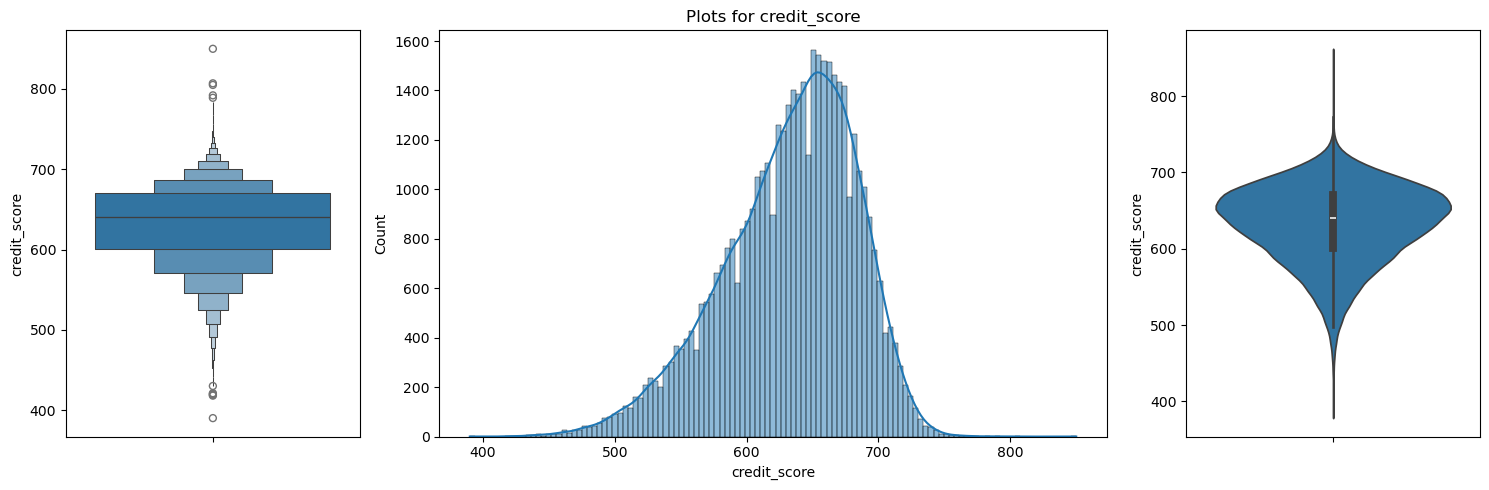

In [25]:
for i in num_features:
    numerical_plots(numeric_data, i)

In [26]:
categorical_data.describe().T

,count,unique,top,freq
person_gender,45000,2,male,24841
person_education,45000,5,Bachelor,13399
person_home_ownership,45000,4,RENT,23443
loan_intent,45000,6,EDUCATION,9153
previous_loan_defaults_on_file,45000,2,Yes,22858


In [45]:
def categorical_plots(data, features):
    print(data[features].value_counts(normalize=True),'\nTotal unique values: ', data[features].nunique())
    ax = sns.countplot(x=data[features])
    ax.bar_label(ax.containers[0])
    plt.xticks(rotation=45)
    plt.show()

person_gender
male      0.552022
female    0.447978
Name: proportion, dtype: float64 
Total unique values:  2


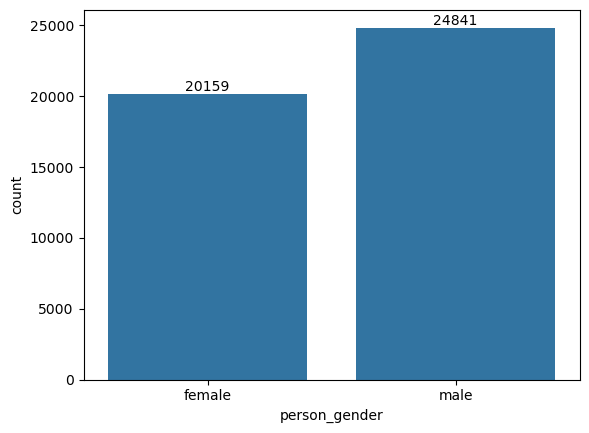

person_education
Bachelor       0.297756
Associate      0.267289
High School    0.266044
Master         0.155111
Doctorate      0.013800
Name: proportion, dtype: float64 
Total unique values:  5


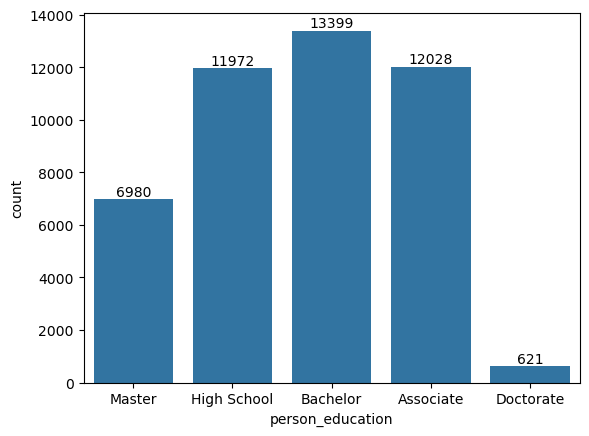

person_home_ownership
RENT        0.520956
MORTGAGE    0.410867
OWN         0.065578
OTHER       0.002600
Name: proportion, dtype: float64 
Total unique values:  4


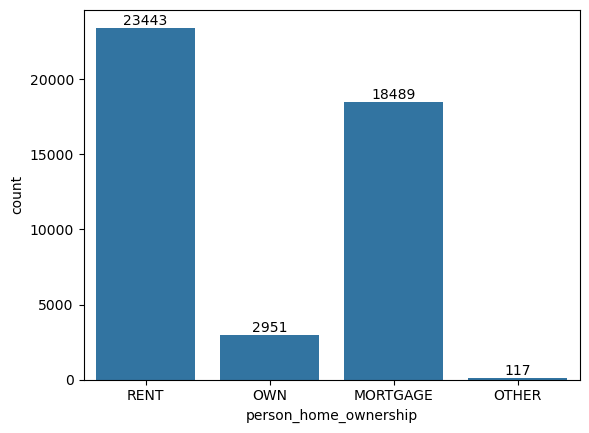

loan_intent
EDUCATION            0.203400
MEDICAL              0.189956
VENTURE              0.173756
PERSONAL             0.167822
DEBTCONSOLIDATION    0.158778
HOMEIMPROVEMENT      0.106289
Name: proportion, dtype: float64 
Total unique values:  6


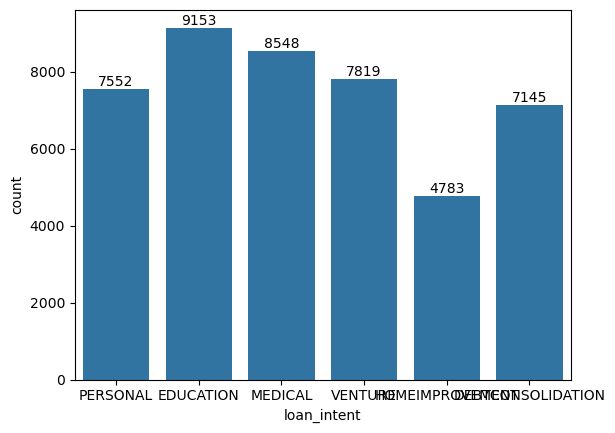

previous_loan_defaults_on_file
Yes    0.507956
No     0.492044
Name: proportion, dtype: float64 
Total unique values:  2


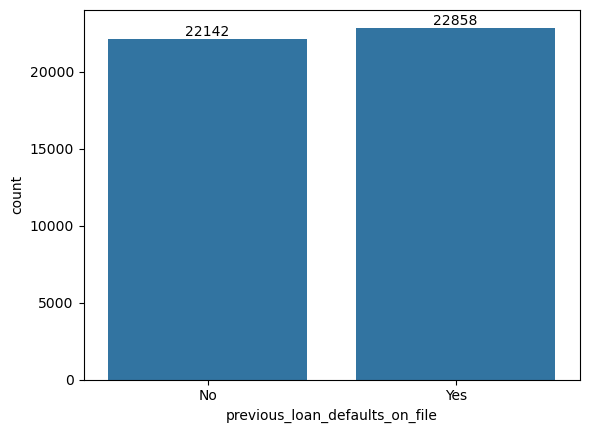

In [28]:
for i in categorical_data.columns:
    categorical_plots(categorical_data, i)

loan_status
0    0.777778
1    0.222222
Name: proportion, dtype: float64 
Total unique values:  2


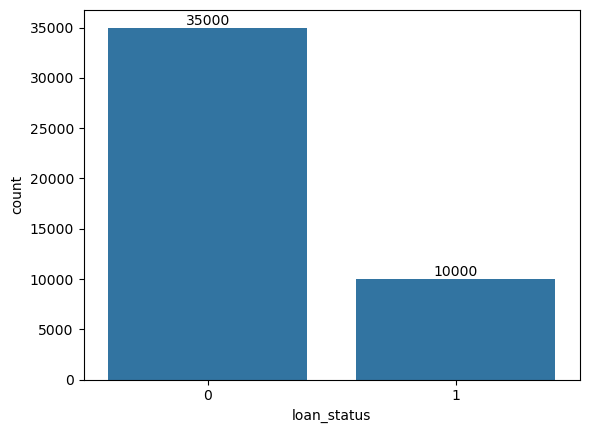

In [29]:
categorical_plots(numeric_data, 'loan_status')

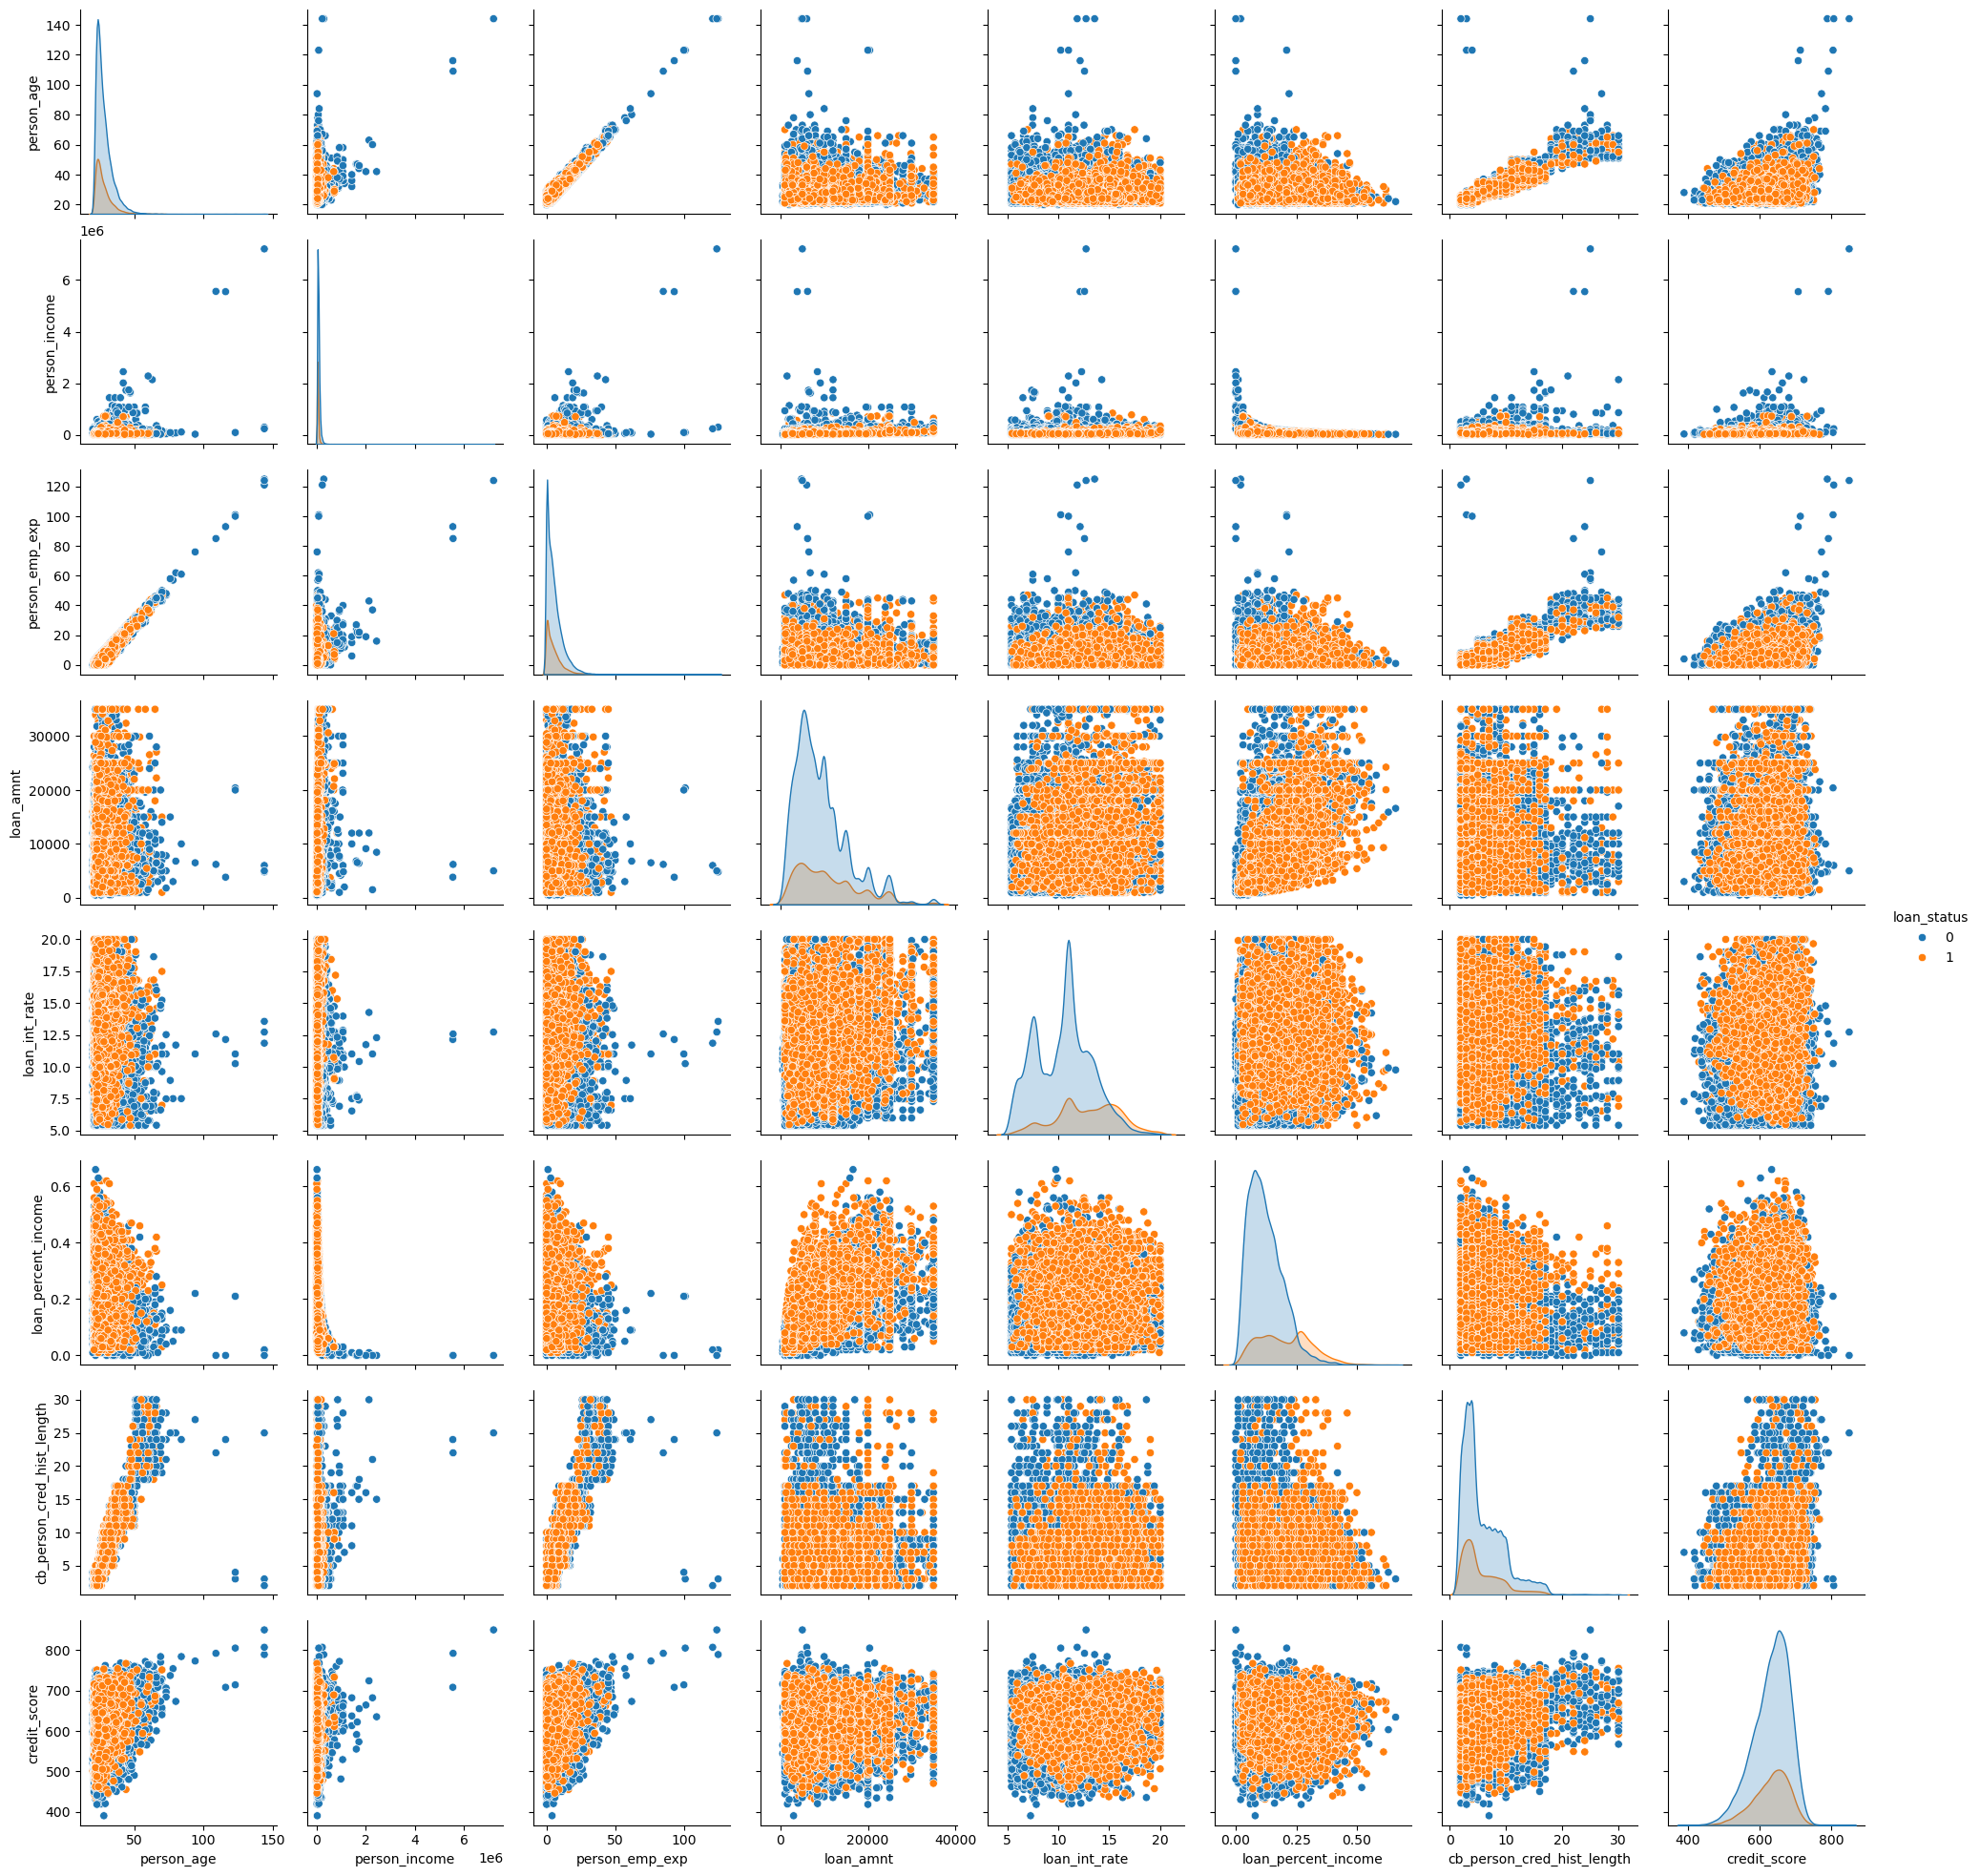

In [30]:
sns.pairplot(numeric_data, hue='loan_status')

## FE

In [31]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, RobustScaler
from sklearn.compose import ColumnTransformer
from feature_engine.outliers import Winsorizer
from sklearn.model_selection import train_test_split

In [32]:
x, y = df.drop(columns='loan_status'), df['loan_status']

In [33]:
# train test split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=0)
x_train.shape, x_test.shape

((36000, 13), (9000, 13))

In [34]:
num_features

Index(['person_age', 'person_income', 'person_emp_exp', 'loan_amnt',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length',
       'credit_score'],
      dtype='str')

In [35]:
cat_cols = categorical_data.columns

In [36]:
from sklearn.pipeline import Pipeline

In [37]:
# pipeline for numeric features
# 1. outlier capping
# 2. scaling --> Robust Scaler

num_pipe = Pipeline(steps=[
    ('outlier_capping', Winsorizer(capping_method='iqr', tail='both', fold=1.5)),
    ('scaler', RobustScaler())
    ])
num_pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('outlier_capping', ...), ('scaler', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,capping_method,'iqr'
,tail,'both'
,fold,1.5
,add_indicators,False
,variables,None
,missing_values,'raise'
,"with_centering with_centering: bool, default=TrueIf `True`, center the data before scaling.This will cause :meth:`transform` to raise an exception when attemptedon sparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True


In [38]:
categorical_data.head()

,person_gender,person_education,person_home_ownership,loan_intent,previous_loan_defaults_on_file
0,female,Master,RENT,PERSONAL,No
1,female,High School,OWN,EDUCATION,Yes
2,female,High School,MORTGAGE,MEDICAL,No
3,female,Bachelor,RENT,MEDICAL,No
4,male,Master,RENT,MEDICAL,No


In [39]:
cat_cols.tolist()

['person_gender',
 'person_education',
 'person_home_ownership',
 'loan_intent',
 'previous_loan_defaults_on_file']

In [40]:
cat_cols = cat_cols[0:1].append(cat_cols[2:])

In [41]:
categorical_data['person_education'].value_counts()

person_education
Bachelor       13399
Associate      12028
High School    11972
Master          6980
Doctorate        621
Name: count, dtype: int64

In [55]:
order_of_education = ['High School', 'Associate', 'Bachelor', 'Master', 'Doctorate']

In [56]:
# transform cols
# 1. num pipe
# 2. ohe
# 3. ordinal encoding --> education
preprocessor = ColumnTransformer(transformers=[
    ('num_pipe', num_pipe, num_features),
    ('ohe', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols),
    ('ordinal', OrdinalEncoder(categories=[order_of_education], handle_unknown='use_encoded_value', unknown_value=-1), ['person_education'])
], remainder='passthrough', verbose_feature_names_out=False)
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num_pipe', ...), ('ohe', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``featu

In [57]:
x_train_transformed = preprocessor.fit_transform(x_train)
x_test_transformed = preprocessor.transform(x_test)

In [58]:
x_test_transformed.shape

(9000, 19)

In [59]:
preprocessor.get_feature_names_out()

array(['person_age', 'person_income', 'person_emp_exp', 'loan_amnt',
       'loan_int_rate', 'loan_percent_income',
       'cb_person_cred_hist_length', 'credit_score', 'person_gender_male',
       'person_home_ownership_OTHER', 'person_home_ownership_OWN',
       'person_home_ownership_RENT', 'loan_intent_EDUCATION',
       'loan_intent_HOMEIMPROVEMENT', 'loan_intent_MEDICAL',
       'loan_intent_PERSONAL', 'loan_intent_VENTURE',
       'previous_loan_defaults_on_file_Yes', 'person_education'],
      dtype=object)

In [60]:
df_x_train_transformed = pd.DataFrame(x_train_transformed, columns=preprocessor.get_feature_names_out())

In [61]:
df_x_train_transformed['person_education'].value_counts()

person_education
2.0    10737
1.0     9597
0.0     9560
3.0     5619
4.0      487
Name: count, dtype: int64

## model building